# Teste de treinamento de modelo para predição de Resistência utilizando HGBR

In [123]:
%%capture
!pip install sklearn optuna

In [124]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

### Montagem do drive

In [125]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_HGBR.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   Cimento_kg_m3                   599 non-null    float64 
 1   Agregado_Graudo_Total_kg_m3     599 non-null    float64 
 2   Superplastificante_kg_m3        554 non-null    float64 
 3   Relacao_Agua_Cimento            599 non-null    float64 
 4   ln_Idade                        599 non-null    float64 
 5   Tipo_Molde_Cod                  599 non-null    int64   
 6   Metodo_Emp_Cod                  599 non-null    int64   
 7   Classe_Cim_OpA                  599 non-null    int64   
 8   Relacao_Agua_Aglomerante        599 non-null    float64 
 9   Filer_D50_um                    299 non-null    float64 
 10  D_Max                           432 non-null    float64 
 11  vol_ar_aprisionado              554 non-null    float64 
 12  porosidade_volumetrica

In [127]:
def split_target(df, target):
    df.drop(columns=['bins'], inplace=True, errors='ignore')
    y = df[target].copy()
    df.drop(columns=[target], inplace=True)
    return df, y

In [128]:
# 1. Separa 70% para treino e 30% para o resto (mantendo a proporção da coluna 'bins')
df_train, df_temp = train_test_split(
    df,
    test_size=0.3, 
    random_state=42, 
    stratify=df['bins']
)

# 2. Dos 30% restantes, divide em Teste (2/3) e Validação (1/3)
# Isso resulta em 20% do total para Teste e 10% para Validação
df_test, df_val = train_test_split(
    df_temp, 
    test_size=0.3333, 
    random_state=42, 
    stratify=df_temp['bins']
)

df_train.to_pickle(os.path.join(dirpath, 'df_train.pkl'))
df_test.to_pickle(os.path.join(dirpath, 'df_test.pkl'))
df_val.to_pickle(os.path.join(dirpath, 'df_val.pkl'))

X_train, y_train = split_target(df_train, 'target')
X_test, y_test = split_target(df_test, 'target')
X_val, y_val = split_target(df_val, 'target')

In [129]:
print(sum([df_train.isna().sum(), df_test.isna().sum(), df_val.isna().sum()]))

Cimento_kg_m3                       0
Agregado_Graudo_Total_kg_m3         0
Superplastificante_kg_m3           45
Relacao_Agua_Cimento                0
ln_Idade                            0
Tipo_Molde_Cod                      0
Metodo_Emp_Cod                      0
Classe_Cim_OpA                      0
Relacao_Agua_Aglomerante            0
Filer_D50_um                      300
D_Max                             167
vol_ar_aprisionado                 45
porosidade_volumetrica_inicial     45
concentracao_agregados              0
finos_total                         0
aglomerante_total                   0
agua_solidos                        0
range_granulometrico              399
parametro_feret                    45
idade_ac_feret                     45
dtype: int64


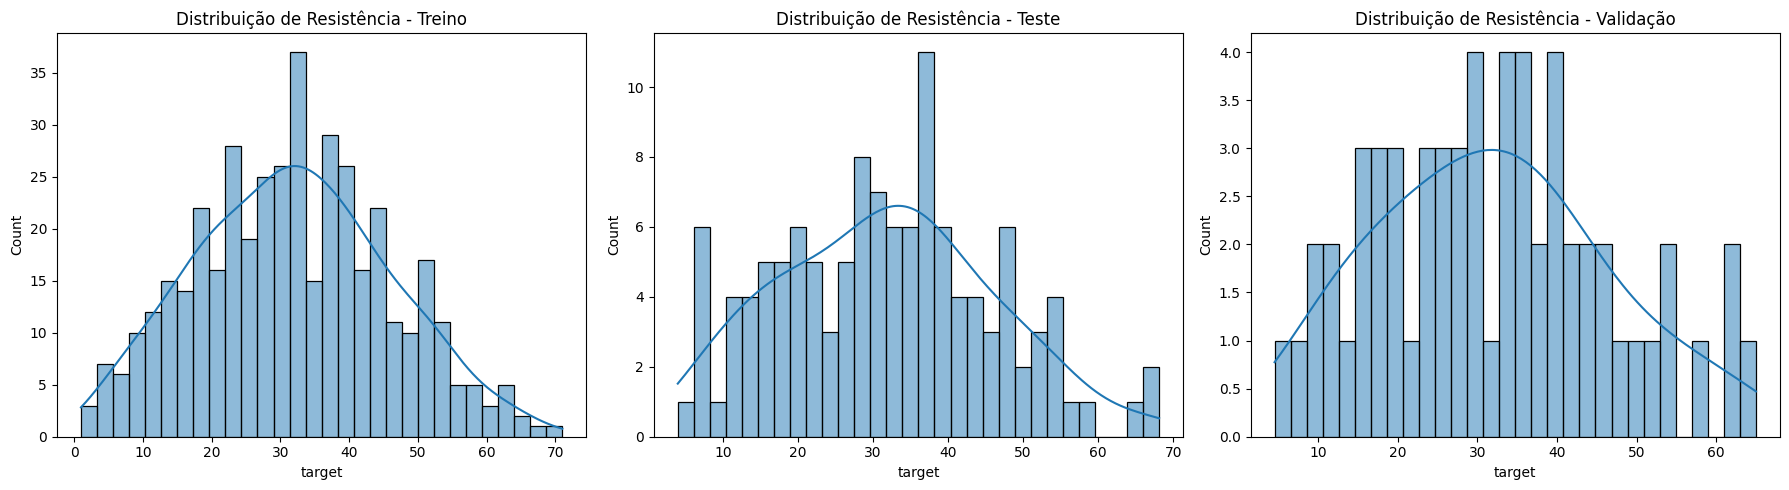

In [130]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Resistência - Treino')
sns.histplot(y_test, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Resistência - Teste')
sns.histplot(y_val, bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribuição de Resistência - Validação')
plt.tight_layout()
plt.show()

In [131]:
print(f"X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\nX_val shape: {X_val.shape}\n")
assert X_train.columns.equals(X_test.columns) and X_train.columns.equals(X_val.columns), "As colunas dos DataFrames de treino, teste e validação não são iguais."
print("X_train" + "\n" + "\n".join(f"{c}: {X_train[c].dtype} (NAs: {X_train[c].isna().sum()})" for c in X_train.columns) + "\n")
print("X_test" + "\n" + "\n".join(f"{c}: {X_test[c].dtype} (NAs: {X_test[c].isna().sum()})" for c in X_test.columns) + "\n")
print("X_val" + "\n" + "\n".join(f"{c}: {X_val[c].dtype} (NAs: {X_val[c].isna().sum()})" for c in X_val.columns) + "\n")

X_train shape: (419, 20)
X_test shape: (120, 20)
X_val shape: (60, 20)

X_train
Cimento_kg_m3: float64 (NAs: 0)
Agregado_Graudo_Total_kg_m3: float64 (NAs: 0)
Superplastificante_kg_m3: float64 (NAs: 34)
Relacao_Agua_Cimento: float64 (NAs: 0)
ln_Idade: float64 (NAs: 0)
Tipo_Molde_Cod: int64 (NAs: 0)
Metodo_Emp_Cod: int64 (NAs: 0)
Classe_Cim_OpA: int64 (NAs: 0)
Relacao_Agua_Aglomerante: float64 (NAs: 0)
Filer_D50_um: float64 (NAs: 202)
D_Max: float64 (NAs: 115)
vol_ar_aprisionado: float64 (NAs: 34)
porosidade_volumetrica_inicial: float64 (NAs: 34)
concentracao_agregados: float64 (NAs: 0)
finos_total: float64 (NAs: 0)
aglomerante_total: float64 (NAs: 0)
agua_solidos: float64 (NAs: 0)
range_granulometrico: float64 (NAs: 273)
parametro_feret: float64 (NAs: 34)
idade_ac_feret: float64 (NAs: 34)

X_test
Cimento_kg_m3: float64 (NAs: 0)
Agregado_Graudo_Total_kg_m3: float64 (NAs: 0)
Superplastificante_kg_m3: float64 (NAs: 8)
Relacao_Agua_Cimento: float64 (NAs: 0)
ln_Idade: float64 (NAs: 0)
Tipo_M

In [132]:
print(f"y_train shape: {y_train.shape}\ny_test shape: {y_test.shape}\ny_val shape: {y_val.shape}\n")
print("y_train" + "\n" + f"{y_train.name}: {y_train.dtype} (NAs: {y_train.isna().sum()})" + "\n")
print("y_test" + "\n" + f"{y_test.name}: {y_test.dtype} (NAs: {y_test.isna().sum()})" + "\n")
print("y_val" + "\n" + f"{y_val.name}: {y_val.dtype} (NAs: {y_val.isna().sum()})" + "\n")

y_train shape: (419,)
y_test shape: (120,)
y_val shape: (60,)

y_train
target: float64 (NAs: 0)

y_test
target: float64 (NAs: 0)

y_val
target: float64 (NAs: 0)



In [133]:
# Exemplo de Monotonic Constraints (-1 para inversa, 1 para direta, 0 para livre)
# Supondo que suas colunas sejam: ['parametro_feret', 'agua_solidos', 'vol_ar', 'log_idade']
# Feret(+), Agua/Solidos(-), Ar(-), Idade(+)
# 1 = Correlação Positiva (Sobe um, sobe o outro)
# -1 = Correlação Negativa (Sobe um, desce o outro)
regras_fisicas = {
    'parametro_feret': 1,                   # Mais concentração de cimento = Maior resistência
    'ln_Idade': 1,                          # Mais tempo = Maior resistência
    'idade_ac': 1,                          # Maior energia de hidratação = Maior resistência
    'Relacao_Agua_Cimento': -1,             # Mais água = Menor resistência
    'Relacao_Agua_Aglomerante': -1,         # Mais água = Menor resistência
    'agua_solidos': -1,                     # Mistura mais diluída = Menor resistência
    'vol_ar_aprisionado': -1,               # Mais vazios = Menor resistência
    'porosidade_volumetrica_inicial': -1    # Mais porosidade = Menor resistência
}

# 2. Gere a lista com 21 zeros automaticamente
restricoes_completas = [0] * len(X_train.columns)

# 3. Preencha os valores corretos baseando-se no nome da coluna
for i, coluna in enumerate(X_train.columns):
    if coluna in regras_fisicas:
        restricoes_completas[i] = regras_fisicas[coluna]
        print(f"Coluna '{coluna}' mapeada para restrição {regras_fisicas[coluna] if coluna in regras_fisicas else 0}.")

print("Lista de restrições de tamanho 21 gerada com sucesso:")
print(restricoes_completas)

hyper_params = {
    "max_bins": 64,                # Reduzido por causa das 419 linhas
    "max_depth": 3,                # Mesma profundidade segura do XGBoost
    "min_samples_leaf": 12,        # Regularização forte na ponta
    "learning_rate": 0.05,
    "max_iter": 250,               # Equivalente ao n_estimators
    "l2_regularization": 10.0,     # Ridge penalty (L2)
    "monotonic_cst": restricoes_completas,   # Injetando as leis da física!
    "random_state": 42,
    "early_stopping": True,      # OBRIGA o modelo a monitorar a validação
    "validation_fraction": 0.15, # Separa 15% do seu X_train internamente para gerar a linha de validação
    "n_iter_no_change": 250,
    "verbose": False
}

Coluna 'Relacao_Agua_Cimento' mapeada para restrição -1.
Coluna 'ln_Idade' mapeada para restrição 1.
Coluna 'Relacao_Agua_Aglomerante' mapeada para restrição -1.
Coluna 'vol_ar_aprisionado' mapeada para restrição -1.
Coluna 'porosidade_volumetrica_inicial' mapeada para restrição -1.
Coluna 'agua_solidos' mapeada para restrição -1.
Coluna 'parametro_feret' mapeada para restrição 1.
Lista de restrições de tamanho 21 gerada com sucesso:
[0, 0, 0, -1, 1, 0, 0, 0, -1, 0, 0, -1, -1, 0, 0, 0, -1, 0, 1, 0]


In [134]:
X_train.columns

Index(['Cimento_kg_m3', 'Agregado_Graudo_Total_kg_m3',
       'Superplastificante_kg_m3', 'Relacao_Agua_Cimento', 'ln_Idade',
       'Tipo_Molde_Cod', 'Metodo_Emp_Cod', 'Classe_Cim_OpA',
       'Relacao_Agua_Aglomerante', 'Filer_D50_um', 'D_Max',
       'vol_ar_aprisionado', 'porosidade_volumetrica_inicial',
       'concentracao_agregados', 'finos_total', 'aglomerante_total',
       'agua_solidos', 'range_granulometrico', 'parametro_feret',
       'idade_ac_feret'],
      dtype='object')

In [135]:
model = HistGradientBoostingRegressor(**hyper_params)

In [136]:
%%time
model.fit(X_train, y_train)

CPU times: user 207 ms, sys: 3.96 ms, total: 211 ms
Wall time: 213 ms


HistGradientBoostingRegressor(early_stopping=True, l2_regularization=10.0,
                              learning_rate=0.05, max_bins=64, max_depth=3,
                              max_iter=250, min_samples_leaf=12,
                              monotonic_cst=[0, 0, 0, -1, 1, 0, 0, 0, -1, 0, 0,
                                             -1, -1, 0, 0, 0, -1, 0, 1, 0],
                              n_iter_no_change=250, random_state=42,
                              validation_fraction=0.15, verbose=False)

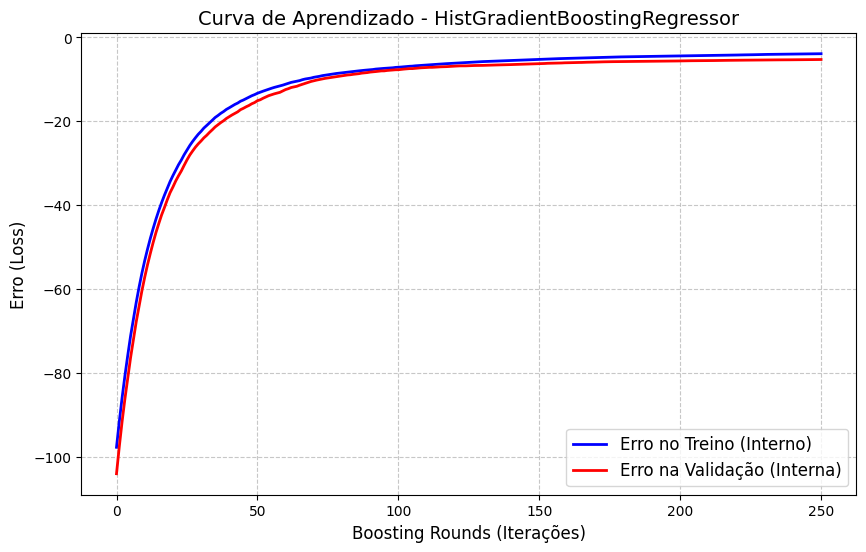

In [137]:
# 3. Extraindo os históricos gravados dentro do modelo
train_rmse = model.train_score_
val_rmse = model.validation_score_
treino_historico = model.train_score_
val_historico = model.validation_score_

# 4. Plotando o Gráfico
plt.figure(figsize=(10, 6))
plt.plot(treino_historico, label='Erro no Treino (Interno)', color='blue', linewidth=2)
plt.plot(val_historico, label='Erro na Validação (Interna)', color='red', linewidth=2)

plt.title('Curva de Aprendizado - HistGradientBoostingRegressor', fontsize=14)
plt.xlabel('Boosting Rounds (Iterações)', fontsize=12)
plt.ylabel('Erro (Loss)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [138]:
# Estatísticas finais
train_final = train_rmse[-1]
val_final = val_rmse[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      -3.883170
⚠️  RMSE Validação (final):   -5.262583
📈 Gap (Val - Train):        -1.379414


In [139]:
# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)
debug_df = X_test.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_test
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

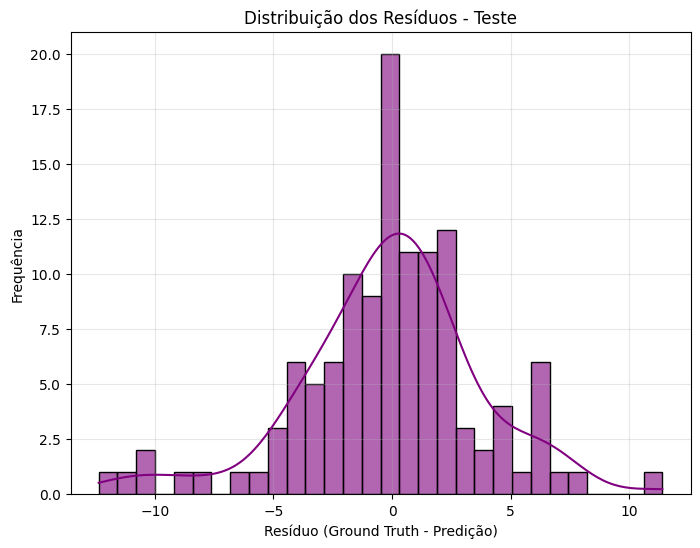

In [140]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Distribuição dos Resíduos - Teste")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

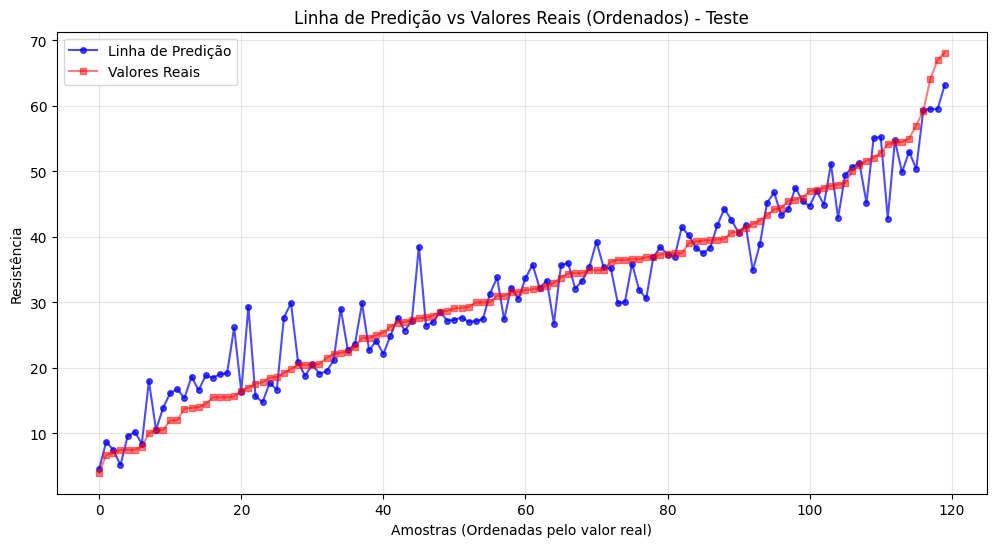

In [141]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Teste")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [142]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 3.8033
mean_absolute_error: 2.7356
mean_absolute_percentage_error: 0.1160
R² Score: 92.8836


In [143]:
y_val_pred = model.predict(X_val)
validation_df = X_val.copy()

validation_df["pred"] = y_val_pred
validation_df["ground_truth"] = y_val
validation_df["residual"] = validation_df["ground_truth"] - validation_df["pred"]

Text(0.5, 1.0, 'Distribuição dos Resíduos - Validação')

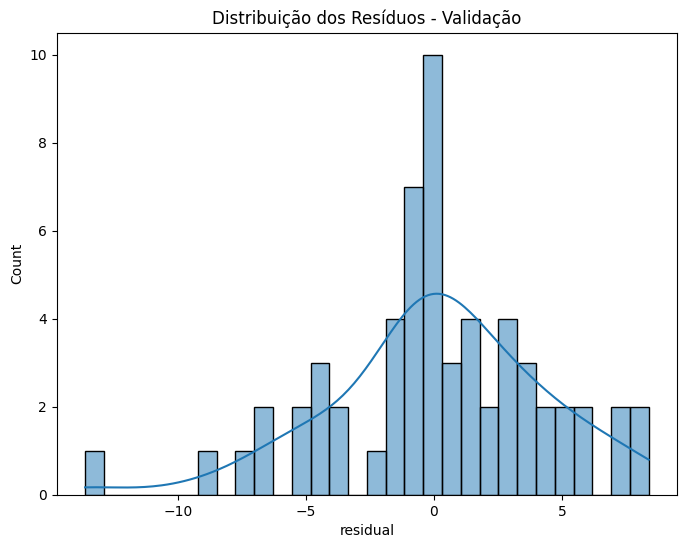

In [144]:
plt.figure(figsize=(8, 6))
sns.histplot(validation_df["residual"], bins=30, kde=True)
plt.title("Distribuição dos Resíduos - Validação")

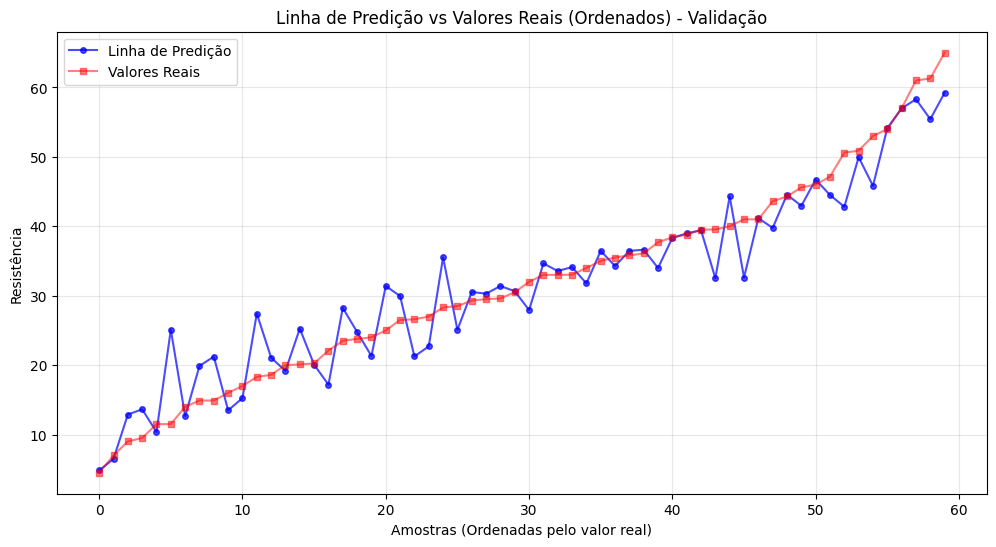

In [145]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
validation_df = validation_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(validation_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, validation_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, validation_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Validação")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [146]:
r2 = r2_score(validation_df["ground_truth"], validation_df["pred"])
rmse = root_mean_squared_error(validation_df["ground_truth"], validation_df["pred"])
mae = mean_absolute_error(validation_df["ground_truth"], validation_df["pred"])
mape = mean_absolute_percentage_error(validation_df["ground_truth"], validation_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 4.1550
mean_absolute_error: 3.0606
mean_absolute_percentage_error: 0.1325
R² Score: 91.6282


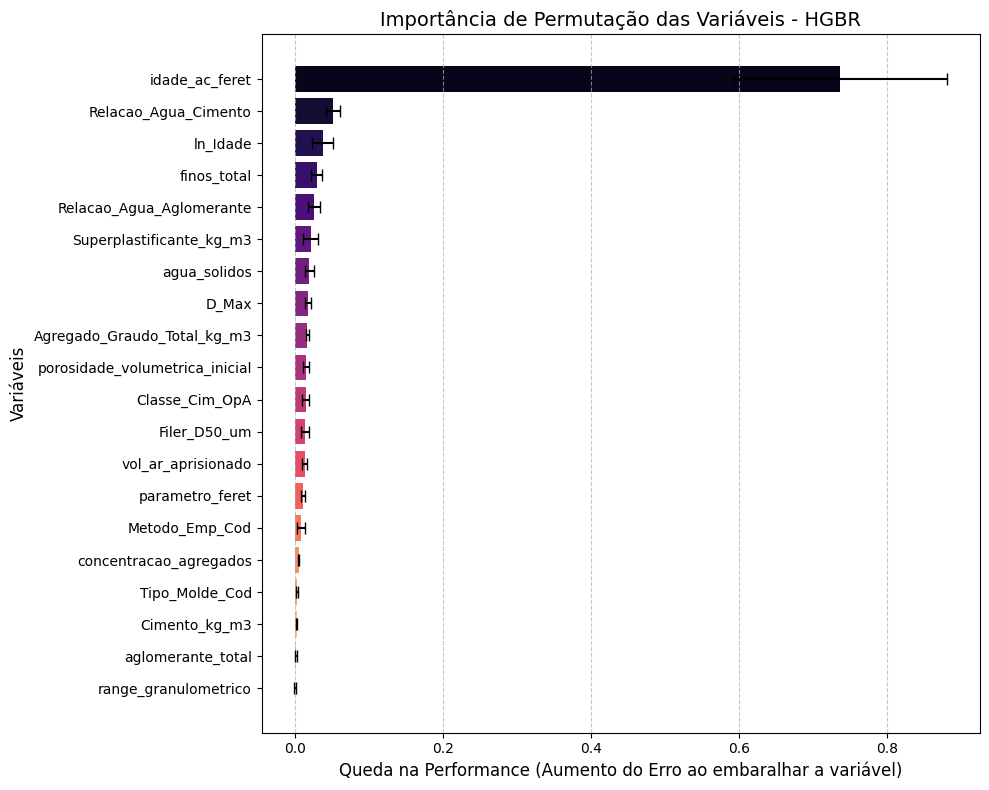

In [147]:
# Isso mostra quais features realmente importam para prever dados NOVOS, e não apenas o que ele decorou.
resultado_permutacao = permutation_importance(
    model, X_val, y_val, 
    n_repeats=10,        # Ele vai embaralhar cada coluna 10 vezes para tirar uma média segura
    random_state=42, 
    n_jobs=-1            # Usa todos os núcleos do seu processador
)

# 2. Criando um DataFrame com os resultados
df_importancia_hgbr = pd.DataFrame({
    'Feature': X_val.columns,
    'Importancia_Media': resultado_permutacao.importances_mean,
    'Desvio_Padrao': resultado_permutacao.importances_std
})

# Ordenando da mais importante para a menos importante
df_importancia_hgbr = df_importancia_hgbr.sort_values(by='Importancia_Media', ascending=False)

# 3. Plotando o Gráfico (Solução sem o bug do Seaborn)
plt.figure(figsize=(10, 8))

# Extraindo a paleta de cores do Seaborn para manter o estilo
cores = sns.color_palette('magma', n_colors=len(df_importancia_hgbr))

# Usando o barh (Bar Horizontal) nativo do Matplotlib, que aceita o xerr perfeitamente
plt.barh(
    y=df_importancia_hgbr['Feature'], 
    width=df_importancia_hgbr['Importancia_Media'],
    xerr=df_importancia_hgbr['Desvio_Padrao'], 
    color=cores,
    capsize=4,        # Coloca aqueles "tracinhos" verticais na ponta da barra de erro
    edgecolor='none'
)

# Invertemos o eixo Y para a feature mais importante ficar no topo
plt.gca().invert_yaxis()

plt.title('Importância de Permutação das Variáveis - HGBR', fontsize=14)
plt.xlabel('Queda na Performance (Aumento do Erro ao embaralhar a variável)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()